<a href="https://colab.research.google.com/github/kenzuroid-tech/244107020014-mobile-course/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM FILTER**

1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa
menggunakan library atau metode konvolusi dari OpenCV.
2. Berikut merupakan langkah-langkah yang dapat dilakukan:
a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan
pada akun github seperti pada modul sebelumnya.
b. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

**Konvolusi tanpa Library**

Membuat fungsi konvolusi
Fungsi konvolusi yang dibuat memiliki parameter berupa
1. citra masukan,
2. kernel berupa matriks untuk memfilter citra,
3. nilai stride / besarnya pergeseran untuk setiap konvolusi,
4. nilai pad yang akan ditambahkan pada citra

In [9]:
def convolution2d(image, kernel, stride, padding):
    # Get image dimensions (supports both grayscale and color)
    if len(image.shape) == 3:
        image_height, image_width, image_channels = image.shape
    else:
        image_height, image_width = image.shape
        image_channels = 1

    # Get kernel dimensions
    kernel_height, kernel_width = kernel.shape

    # Calculate output dimensions
    output_height = int(((image_height - kernel_height + 2 * padding) / stride) + 1)
    output_width = int(((image_width - kernel_width + 2 * padding) / stride) + 1)

    # Handle padding (Zero Padding)
    if padding > 0:
        if image_channels > 1:
            padded_image = np.zeros((image_height + 2 * padding, image_width + 2 * padding, image_channels))
            padded_image[padding:-padding, padding:-padding, :] = image
        else:
            padded_image = np.zeros((image_height + 2 * padding, image_width + 2 * padding))
            padded_image[padding:-padding, padding:-padding] = image
    else:
        padded_image = image

    # Initialize output array
    if image_channels > 1:
        output = np.zeros((output_height, output_width, image_channels))
        # Perform convolution on each channel
        for c in range(image_channels):
            for y in range(0, output_height):
                for x in range(0, output_width):
                    # Extract current region of interest
                    roi = padded_image[y*stride:y*stride + kernel_height, x*stride:x*stride + kernel_width, c]
                    # Element-wise multiplication and sum
                    output[y, x, c] = np.sum(roi * kernel)
    else:
        output = np.zeros((output_height, output_width))
        # Perform convolution for 2D grayscale image
        for y in range(0, output_height):
            for x in range(0, output_width):
                # Extract current region of interest
                roi = padded_image[y*stride:y*stride + kernel_height, x*stride:x*stride + kernel_width]
                # Element-wise multiplication and sum
                output[y, x] = np.sum(roi * kernel)

    return output

d. Load citra yang akan diproses dan ubah menjadi citra keabuan

In [4]:
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

e. Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening
sebagai berikut:


In [18]:
# image sharpen
kernel_sharpen = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

In [19]:
convolution2d(img_gray, kernel_sharpen, 1, 2)

array([[   0., -145.,  -56., ..., -153., -177.,    0.],
       [-145.,  553.,  -15., ...,  326.,  607., -177.],
       [-116.,  257.,  179., ...,  249.,  218., -125.],
       ...,
       [-156.,  487.,  262., ...,  159.,  183.,  -69.],
       [ -11., -112., -110., ...,  -71.,  -53.,   -4.],
       [   0.,  -11.,  -11., ...,   -4.,   -4.,    0.]])

3. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:

a. Operasi Sharpen

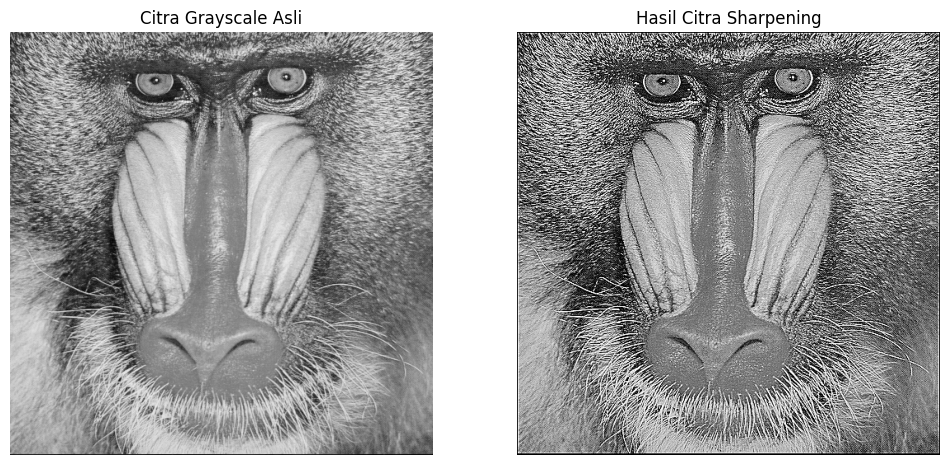

In [21]:
output_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

output_sharpen_clean = np.clip(output_sharpen, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Citra Grayscale Asli')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hasil Citra Sharpening')
plt.imshow(output_sharpen_clean, cmap='gray')
plt.axis('off')

plt.show()

b. Operasi Emboss

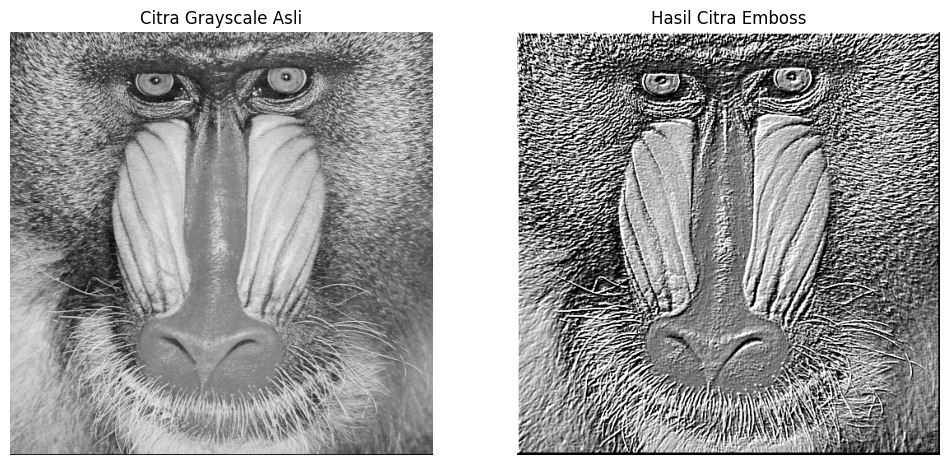

In [32]:
kernel_emboss = np.array([[-2, -1, 0],
                         [-1, 1, 1],
                         [0, 1, 2]])

output_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)

output_emboss_clean = np.clip(output_emboss, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Citra Grayscale Asli')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hasil Citra Emboss')
plt.imshow(output_emboss_clean, cmap='gray')
plt.axis('off')

plt.show()

c. Operasi Left Sobel Edge Detection

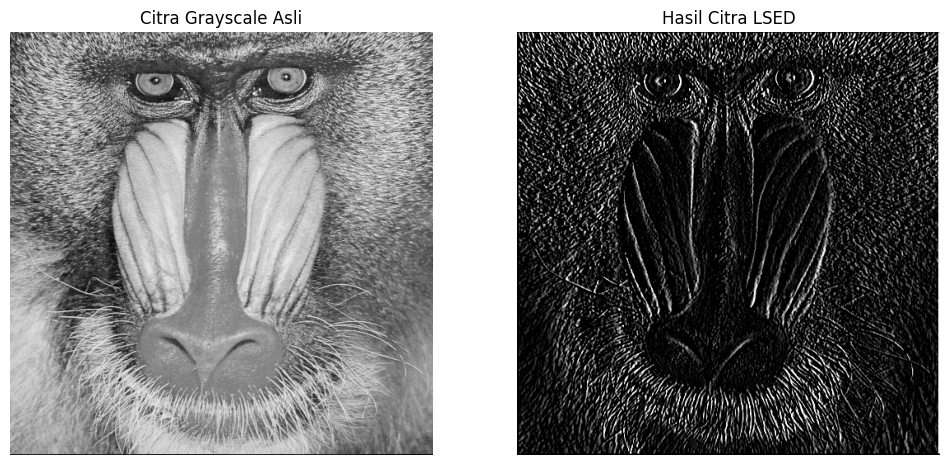

In [30]:
kernel_LSED = np.array([[1, 0, -1],
                         [2, 0, -2],
                         [1, 0, -1]])

output_LSED = convolution2d(img_gray, kernel_LSED, 1, 2)

output_LSED_clean = np.clip(output_LSED, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Citra Grayscale Asli')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hasil Citra LSED')
plt.imshow(output_LSED_clean, cmap='gray')
plt.axis('off')

plt.show()

d. Operasi Canny Edge Detection

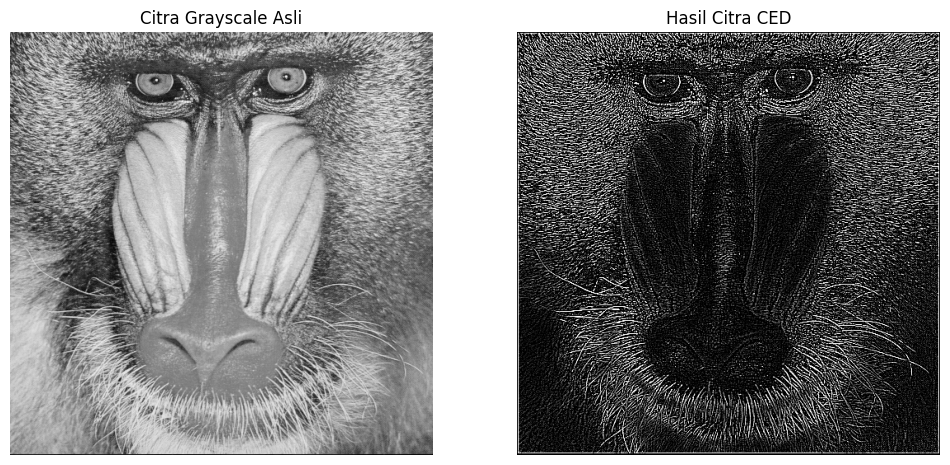

In [35]:
kernel_CED = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])

output_CED = convolution2d(img_gray, kernel_CED, 1, 2)

output_CED_clean = np.clip(output_CED, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Citra Grayscale Asli')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hasil Citra CED')
plt.imshow(output_CED_clean, cmap='gray')
plt.axis('off')

plt.show()

e. Operasi 21 x 21 Gaussian Blur

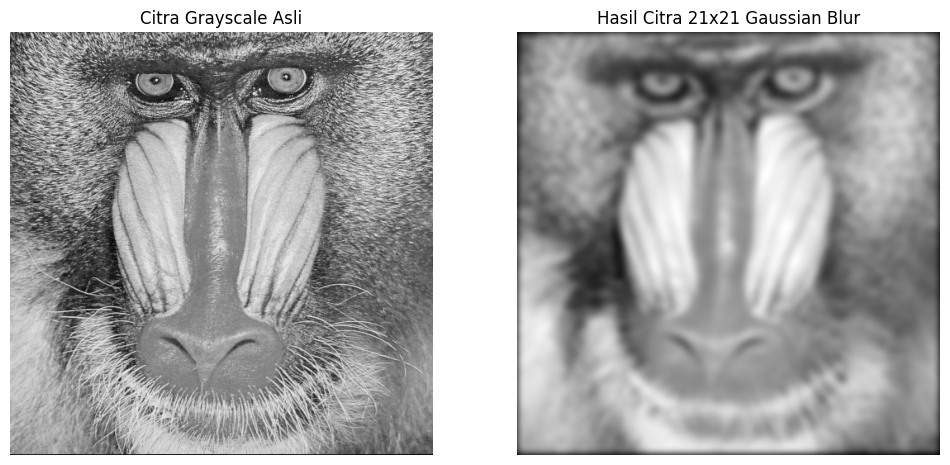

In [37]:
kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

output_blur = convolution2d(img_gray, gauss_kernel, 1, 10)
output_blur_clean = np.clip(output_blur, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Citra Grayscale Asli')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Hasil Citra 21x21 Gaussian Blur')
plt.imshow(output_blur_clean, cmap='gray')
plt.axis('off')

plt.show()

**FILTER LIBRARY DAN FILTER MODERN**

Pada beberapa percobaan berikut ini kita akan melihat beberapa filter menggunakan library, filter
modern yang digunakan pada CNN, filter modern dengan kombinasi beberapa filter tradisional (tanpa
Deep Learning).

Percobaan 1:

Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

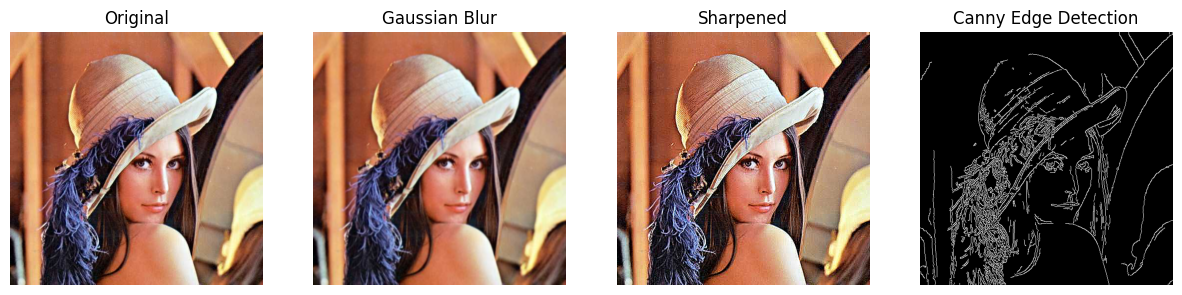

In [42]:
# Fungsi tampil berdampingan yang diperbaiki
def show_side_by_side(images, titles, figsize=(15, 5)):
  plt.figure(figsize=figsize)
  for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, len(images), i+1)
    if len(image.shape) == 2: # memeriksa dimensi dari gambar lokal (image)
      plt.imshow(image, cmap='gray')
    else: # color
      plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB)) # mengubah warna dari BGR ke RGB
    plt.title(title)
    plt.axis("off")
  plt.show()

# Membaca gambar
img = cv.imread('/content/drive/MyDrive/PVCK/GAMBAR/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Proses filter menggunakan OpenCV library
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

# Memanggil fungsi untuk menampilkan secara berdampingan
show_side_by_side([img, blur, sharpened, edges], ["Original", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2:

Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan
digunakan adalah Bilateral Filtering dan Guided Filter. Bilateral filtering adalah sebuah metode
penyaringan non-linear yang banyak digunakan untuk menghaluskan citra sekaligus tetap
mempertahankan ketajaman tepi. Berbeda dengan Gaussian blur biasa yang hanya memperhitungkan
jarak spasial antar piksel, bilateral filter juga mempertimbangkan perbedaan intensitas warna. Dengan
cara ini, piksel-piksel yang letaknya dekat dan memiliki warna mirip dengan pusat jendela akan
mendapat bobot lebih besar dalam perhitungan, sedangkan piksel dengan perbedaan warna kontras
(misalnya di sisi tepi) akan tereduksi pengaruhnya. Akibatnya, citra menjadi lebih halus pada area
datar, namun garis batas dan detail penting tetap terjaga. Meskipun menghasilkan kualitas yang baik,
bilateral filter tergolong lambat karena perhitungan bobot yang cukup kompleks. Dalam praktiknya,
filter ini banyak dipakai untuk keperluan seperti perbaikan kualitas foto, pengurangan noise, maupun
sebagai dasar dari efek beauty filter untuk melembutkan tekstur kulit tanpa mengaburkan kontur
wajah.

**Guided filtering** merupakan teknik yang lebih modern dan efisien. Filter ini didasarkan pada asumsi
bahwa, dalam sebuah jendela lokal, hasil penyaringan dapat direpresentasikan sebagai fungsi linear
dari citra pemandu (guide image). Artinya, setiap piksel keluaran dihitung dengan mempertimbangkan
hubungan linier antara nilai piksel di citra masukan dengan nilai piksel pada citra pemandu. Jika citra
masukan dan citra pemandu sama, guided filter akan berperan mirip bilateral filter namun dengan
perhitungan yang jauh lebih cepat dan hasil yang lebih halus. Keunggulan lainnya, guided filter bisa
menggunakan citra yang berbeda sebagai pemandu sehingga mampu mengarahkan proses filtering
sesuai kebutuhan. Berkat sifat ini, guided filter sering dipakai dalam berbagai aplikasi lanjutan seperti
HDR tone mapping, peningkatan detail, image matting, feathering, serta pemurnian depth map pada
sistem stereo vision. Secara umum, guided filter menawarkan keseimbangan antara preservasi tepi
yang baik, kualitas visual yang halus, dan efisiensi komputasi, sehingga dianggap sebagai
penyempurnaan dari pendekatan bilateral filtering.

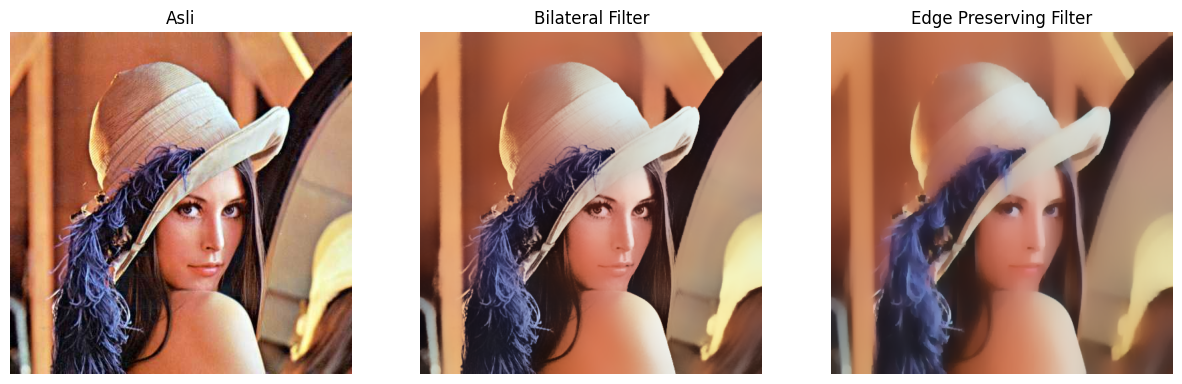

In [43]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ['Asli', 'Bilateral Filter', 'Edge Preserving Filter'])

Percobaan 3:

Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan
running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil
keluaran tersebut.

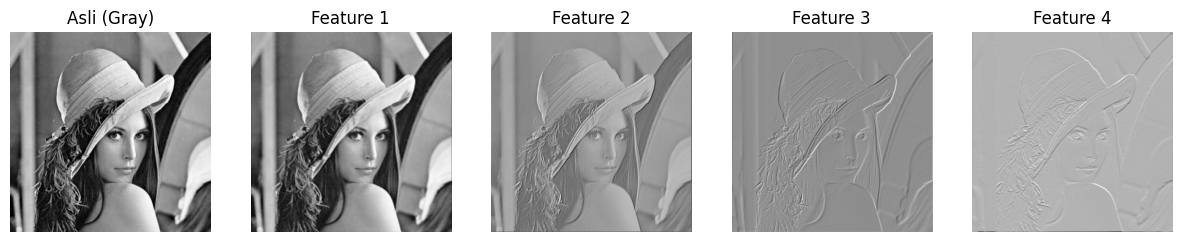

In [44]:
# Filter Featur Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    return self.conv1(x)

model = SimpleCNN()

# Ubah Gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Asli (Gray)'] + [f'Feature {i+1}' for i in range(len(feature_maps))])

Percobaan 4:

Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui
untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular
bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.